In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\data\placement_predict_50k Dataset_final.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (10000, 45)


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
0,-0.540266,-1.159080,-1.064481,-1.137401,-1.035531,-0.998604,-1.056297,-1.380776,-0.850175,-1.021957,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,-1.215032,-0.277425,0.219222,-0.293950,-0.221499,-0.200163,-0.096825,0.003680,-0.307593,-0.169077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.890055,0.623969,0.545035,0.285520,0.961391,0.686295,0.488827,0.883578,0.326435,0.516936,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.124963,0.637128,0.577616,0.729780,0.204596,0.516547,0.694428,0.545156,0.826342,0.609640,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
4,-0.494443,0.702924,1.085884,0.761973,1.279373,1.063511,1.261389,0.871272,0.960463,1.091703,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [4]:
# ------------------------------------------------------------
# Select placed students
# ------------------------------------------------------------
placed_df = df[df["Salary Package"] > 0].copy()

print("Placed students:", len(placed_df))



Placed students: 3663


In [5]:
# ------------------------------------------------------------
# Simple Linear Regression
# X = CGPA
# y = Salary Package
# ------------------------------------------------------------
X = placed_df[["CGPA"]]
y = placed_df["Salary Package"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2930, 1)
X_test : (733, 1)
y_train: (2930,)
y_test : (733,)


In [6]:
#Standardize CGPA for Gradient Descent


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original CGPA:")
print(X_train.head())

print("\nStandardized CGPA:")
print(X_train_scaled[:5])

Original CGPA:
          CGPA
9400  0.622001
91    0.337707
7657  0.628181
7185  1.128785
7245  1.703552

Standardized CGPA:
[[-0.57032243]
 [-1.05118658]
 [-0.55986886]
 [ 0.28687018]
 [ 1.25905204]]


In [7]:
#Batch Gradient Descent from scratch

# Convert to NumPy arrays
X_gd = X_train_scaled.flatten()
y_gd = y_train.to_numpy()

m = len(X_gd)

# Initialize parameters
theta_0 = 0.0
theta_1 = 0.0

learning_rate = 0.01
epochs = 1000

loss_history = []

# ------------------------------------------------------------
# Batch Gradient Descent
# ------------------------------------------------------------
for epoch in range(epochs):

    # Prediction
    y_pred = theta_0 + theta_1 * X_gd
    print(" theta_0:", theta_0)
    print(" theta_1:", theta_1)

    # Error
    error = y_pred - y_gd

    # MSE
    mse = np.mean(error ** 2)
    loss_history.append(mse)

    # Gradients
    gradient_theta_0 = (2 / m) * np.sum(error)
    gradient_theta_1 = (2 / m) * np.sum(error * X_gd)

    # Parameter update
    theta_0 -= learning_rate * gradient_theta_0
    theta_1 -= learning_rate * gradient_theta_1

print("Final theta_0:", theta_0)
print("Final theta_1:", theta_1)
print("Final training MSE:", loss_history[-1])

 theta_0: 0.0
 theta_1: 0.0
 theta_0: 0.02312944389642689
 theta_1: 0.005143076612651314
 theta_0: 0.045796298914925246
 theta_1: 0.010183291693049601
 theta_0: 0.06800981683305363
 theta_1: 0.015122702471839923
 theta_0: 0.08977906439281945
 theta_1: 0.01996332503505444
 theta_0: 0.11111292700138996
 theta_1: 0.024707135147004664
 theta_0: 0.13202011235778904
 theta_1: 0.029356069056715884
 theta_0: 0.15250915400706017
 theta_1: 0.03391202428823288
 theta_0: 0.17258841482334586
 theta_1: 0.038376860415119535
 theta_0: 0.19226609042330584
 theta_1: 0.042752399819468455
 theta_0: 0.2115502125112666
 theta_1: 0.0470404284357304
 theta_0: 0.23044865215746815
 theta_1: 0.0512426964796671
 theta_0: 0.24896912301074567
 theta_1: 0.05536091916272507
 theta_0: 0.26711918444695765
 theta_1: 0.05939677739212188
 theta_0: 0.28490624465444536
 theta_1: 0.06335191845693075
 theta_0: 0.30233756365778336
 theta_1: 0.06722795670044344
 theta_0: 0.3194202562810546
 theta_1: 0.07102647417908589
 theta_0

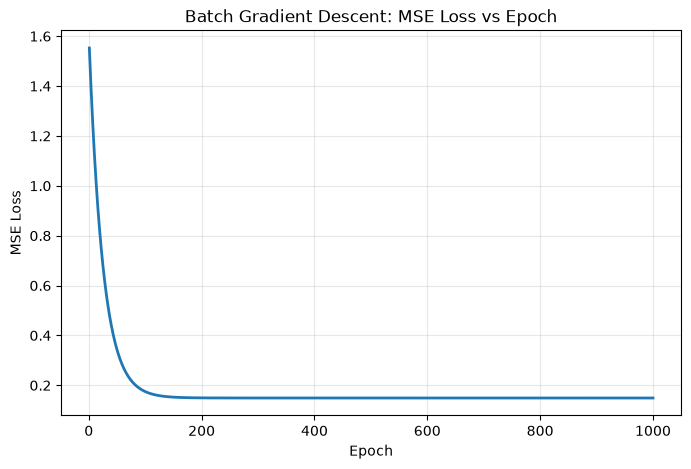

In [8]:
#MSE Curve loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Batch Gradient Descent: MSE Loss vs Epoch")
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
X_test_gd = X_test_scaled.flatten()

y_test_pred_gd = theta_0 + theta_1 * X_test_gd

gd_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_gd)
)

gd_mae = mean_absolute_error(
    y_test,
    y_test_pred_gd
)

gd_r2 = r2_score(
    y_test,
    y_test_pred_gd
)

print("Batch GD RMSE:", gd_rmse)
print("Batch GD MAE :", gd_mae)
print("Batch GD R²  :", gd_r2)

Batch GD RMSE: 0.38897926071259503
Batch GD MAE : 0.32834674669446723
Batch GD R²  : 0.2540715175172972


In [10]:
#Compare with sklearn LinearRegression
sk_model = LinearRegression()

sk_model.fit(
    X_train_scaled,
    y_train
)

y_test_pred_sk = sk_model.predict(
    X_test_scaled
)

sk_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_sk)
)

sk_mae = mean_absolute_error(
    y_test,
    y_test_pred_sk
)

sk_r2 = r2_score(
    y_test,
    y_test_pred_sk
)

print("Sklearn RMSE:", sk_rmse)
print("Sklearn MAE :", sk_mae)
print("Sklearn R²  :", sk_r2)

Sklearn RMSE: 0.3889792607693915
Sklearn MAE : 0.3283467469369411
Sklearn R²  : 0.254071517299465


In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Batch Gradient Descent",
        "sklearn LinearRegression"
    ],
    "RMSE": [
        gd_rmse,
        sk_rmse
    ],
    "MAE": [
        gd_mae,
        sk_mae
    ],
    "R²": [
        gd_r2,
        sk_r2
    ]
})

display(comparison)

,Model,RMSE,MAE,R²
0,Batch Gradient Descent,0.388979,0.328347,0.254072
1,sklearn LinearRegression,0.388979,0.328347,0.254072


## Using "Mini-Batch Gradient Descent" 

In [12]:
# ------------------------------------------------------------
# Mini-Batch Gradient Descent
# ------------------------------------------------------------

X_mb = X_train_scaled.flatten()
y_mb = y_train.to_numpy()

batch_size = 32
epochs_mb = 1000
learning_rate_mb = 0.01

theta_0_mb = 0.0
theta_1_mb = 0.0

mini_batch_loss = []

rng = np.random.default_rng(42)

n_samples = len(X_mb)

for epoch in range(epochs_mb):

    # Shuffle training data
    indices = rng.permutation(n_samples)

    X_shuffled = X_mb[indices]
    y_shuffled = y_mb[indices]

    # Process mini-batches
    for start in range(0, n_samples, batch_size):

        end = start + batch_size

        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        batch_n = len(X_batch)

        # Prediction
        y_batch_pred = (
            theta_0_mb +
            theta_1_mb * X_batch
        )

        # Error
        error = y_batch_pred - y_batch

        # Gradients
        grad_0 = (2 / batch_n) * np.sum(error)

        grad_1 = (
            (2 / batch_n) *
            np.sum(error * X_batch)
        )

        # Update
        theta_0_mb -= learning_rate_mb * grad_0
        theta_1_mb -= learning_rate_mb * grad_1

    # Calculate full training loss after each epoch
    y_epoch_pred = (
        theta_0_mb +
        theta_1_mb * X_mb
    )

    epoch_mse = np.mean(
        (y_epoch_pred - y_mb) ** 2
    )

    mini_batch_loss.append(epoch_mse)

print("Final theta_0:", theta_0_mb)
print("Final theta_1:", theta_1_mb)
print("Final MSE:", mini_batch_loss[-1])

Final theta_0: 1.1560353903562888
Final theta_1: 0.2563666156449086
Final MSE: 0.14906422314197706


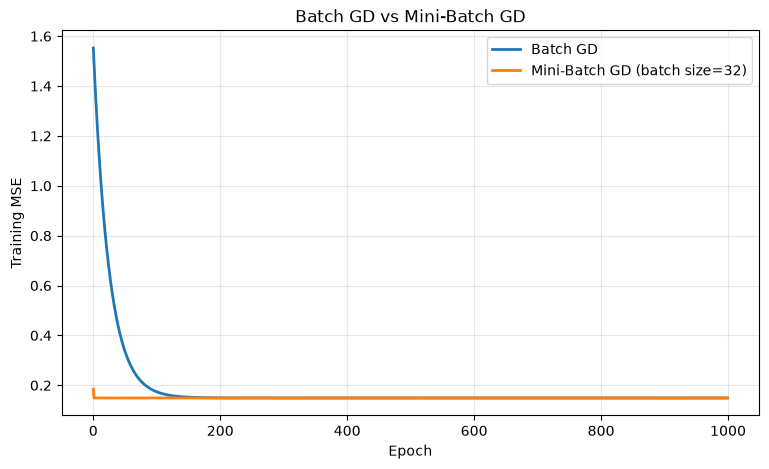

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    loss_history,
    label="Batch GD",
    linewidth=2
)

plt.plot(
    mini_batch_loss,
    label="Mini-Batch GD (batch size=32)",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Batch GD vs Mini-Batch GD")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()